# NB11 Fixed-Model Partition Check — 10 Test-Set Partitions, Zero Retraining

> **Updated for BCE loss (v2_bce).** Loads `gp_predictions_v2_bce.csv` (GP c=24, seed=14). All output paths updated to `results/v2_bce/...`. Findings stale until re-run.

**Purpose:** How much does each model's score wobble purely because of which patients happen to land in a test sample, holding every model completely fixed?

The canonical test set (n=2,233) is split into **10 non-overlapping, stratified groups** (~223 patients each). Metrics are computed within each group using predictions already saved to disk — no retraining, no PySR, no model fitting.

**Why this differs from NB11_repro_runs:** NB11_repro_runs retrains every model fresh on 30 different partitions (measuring combined training + test data variability, with a different GP formula every run). This notebook holds every model completely fixed — same GP formula (c=24, seed=14), same already-fitted LR/RF/XGB/LR_platt/RF_platt — and only varies which patients are scored.

## Inputs

| File | Description |
|---|---|
| `data/processed/gp_predictions_v2_bce.csv` | GP (c=24) probabilities — 2,233 canonical test patients |
| `data/processed/baseline_test_predictions.csv` | LR, RF, XGB, LR_platt, RF_platt predictions — same 2,233 patients |

## Outputs

| File | Description |
|---|---|
| `results/v2_bce/tables/NB11_partition_check_metrics.csv` | 10 groups × 6 models |
| `results/v2_bce/tables/NB11_partition_check_best_avg_worst.csv` | Best/Average/Worst/Stdev across 10 groups |
| `results/v2_bce/tables/NB11_partition_check_wilcoxon.csv` | One-sample Wilcoxon on n=10 paired per-group differences |
| `results/v2_bce/figures/NB11_partition_check_boxplot.pdf/.png` | Box plots of AUROC and ECE (no in-figure title) |

## Runtime

Seconds — no model fitting of any kind.

In [1]:
%matplotlib inline
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys, warnings
warnings.filterwarnings("ignore")

_nb_dir   = Path().resolve()
PROJECT   = _nb_dir.parent if _nb_dir.name == "notebooks" else _nb_dir
DATA_PROC = PROJECT / "data" / "processed"
RESULTS_VERSION = "v2_bce"
TABLES    = PROJECT / "results" / RESULTS_VERSION / "tables"
FIGURES   = PROJECT / "results" / RESULTS_VERSION / "figures"

if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))
from src.metrics import compute_metrics

# ── Load existing predictions — no retraining, no new predictions generated ──
gp_df = pd.read_csv(DATA_PROC / "gp_predictions_v2_bce.csv")
bl_df = pd.read_csv(DATA_PROC / "baseline_test_predictions.csv")

assert gp_df["patientunitstayid"].is_unique
assert bl_df["patientunitstayid"].is_unique

test = gp_df[["patientunitstayid", "hospitalid", "hospital_mortality", "gp_prob"]].copy()
test = test.merge(bl_df[["patientunitstayid", "lr_pred", "rf_pred", "xgb_pred",
                          "lr_platt_pred", "rf_platt_pred"]],
                   on="patientunitstayid", how="left")
assert len(test) == len(gp_df), "Row count changed after merge"
assert test[["lr_pred", "rf_pred", "xgb_pred", "lr_platt_pred", "rf_platt_pred"]].notna().all().all()

MODELS = {
    "GP (c=24)": "gp_prob",
    "LR":        "lr_pred",
    "RF":        "rf_pred",
    "XGB":       "xgb_pred",
    "LR_platt":  "lr_platt_pred",
    "RF_platt":  "rf_platt_pred",
}

y_true = test["hospital_mortality"].to_numpy(dtype=int)
print(f"Results version : {RESULTS_VERSION}")
print(f"Canonical test set: {len(test):,} patients, positive rate {y_true.mean()*100:.2f}%")
print(f"Models (fixed, no retraining): {list(MODELS.keys())}")
print("Note: APACHE-IV excluded — its coverage mask (899 missing) creates")
print("      unevenly-sized subgroups, not essential to this question.")

Results version : v2_bce
Canonical test set: 2,233 patients, positive rate 16.88%
Models (fixed, no retraining): ['GP (c=24)', 'LR', 'RF', 'XGB', 'LR_platt', 'RF_platt']
Note: APACHE-IV excluded — its coverage mask (899 missing) creates
      unevenly-sized subgroups, not essential to this question.


In [2]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
group_rows = []

for group_idx, (_, group_indices) in enumerate(skf.split(test, y_true)):
    yt_group = y_true[group_indices]
    for model_name, col in MODELS.items():
        pp_group = test[col].to_numpy()[group_indices]
        m = compute_metrics(yt_group, np.clip(pp_group, 1e-7, 1 - 1e-7), label=model_name)
        m["model"] = model_name
        m["group"] = group_idx + 1
        m["n"] = len(yt_group)
        m["n_pos"] = int(yt_group.sum())
        group_rows.append(m)

group_df = pd.DataFrame(group_rows)
out_groups = TABLES / "NB11_partition_check_metrics.csv"
group_df.to_csv(out_groups, index=False)

print(f"Saved: {out_groups}  ({len(group_df)} rows = 10 groups x {len(MODELS)} models)")
print()
print("Group sizes and event counts (stratified):")
sizes = group_df[group_df["model"] == "GP (c=24)"][["group", "n", "n_pos"]]
print(sizes.to_string(index=False))
print()
print("AUROC / ECE per group, GP (c=24):")
gp_rows = group_df[group_df["model"] == "GP (c=24)"]
for _, r in gp_rows.iterrows():
    print(f"  Group {int(r['group']):>2}: n={int(r['n']):>4}  AUROC={r['auroc']:.4f}  ECE={r['ece_10bin']:.4f}")

Saved: C:\ML PROJECT\sepsis-gp\results\v2_bce\tables\NB11_partition_check_metrics.csv  (60 rows = 10 groups x 6 models)

Group sizes and event counts (stratified):
 group   n  n_pos
     1 224     38
     2 224     38
     3 224     38
     4 223     37
     5 223     37
     6 223     37
     7 223     38
     8 223     38
     9 223     38
    10 223     38

AUROC / ECE per group, GP (c=24):
  Group  1: n= 224  AUROC=0.7476  ECE=0.0356
  Group  2: n= 224  AUROC=0.8366  ECE=0.0647
  Group  3: n= 224  AUROC=0.7267  ECE=0.0354
  Group  4: n= 223  AUROC=0.8123  ECE=0.0517
  Group  5: n= 223  AUROC=0.7682  ECE=0.0403
  Group  6: n= 223  AUROC=0.6931  ECE=0.0360
  Group  7: n= 223  AUROC=0.6954  ECE=0.0356
  Group  8: n= 223  AUROC=0.6532  ECE=0.0430
  Group  9: n= 223  AUROC=0.6909  ECE=0.0415
  Group 10: n= 223  AUROC=0.7438  ECE=0.0259


Best / Average / Worst / Stdev across 10 non-overlapping test-set partitions:
    model    metric   best  average  worst  stdev
GP (c=24)     auroc 0.8366   0.7368 0.6532 0.0574
GP (c=24)     auprc 0.6375   0.4492 0.2705 0.1012
GP (c=24) ece_10bin 0.0259   0.0410 0.0647 0.0107
GP (c=24)     brier 0.1013   0.1202 0.1380 0.0100
       RF     auroc 0.8463   0.7765 0.7292 0.0430
       RF     auprc 0.6173   0.4854 0.3421 0.0867
       RF ece_10bin 0.0967   0.1224 0.1404 0.0125
       RF     brier 0.1181   0.1299 0.1395 0.0081
 RF_platt     auroc 0.8463   0.7765 0.7292 0.0430
 RF_platt     auprc 0.6173   0.4854 0.3421 0.0867
 RF_platt ece_10bin 0.0310   0.0488 0.0757 0.0136
 RF_platt     brier 0.1001   0.1153 0.1315 0.0101
      XGB     auroc 0.8534   0.7678 0.6807 0.0537
      XGB     auprc 0.6123   0.4616 0.3121 0.0984
      XGB ece_10bin 0.0764   0.1187 0.1391 0.0195
      XGB     brier 0.1225   0.1411 0.1638 0.0141
       LR     auroc 0.8437   0.7669 0.6533 0.0547
       LR     auprc 0.

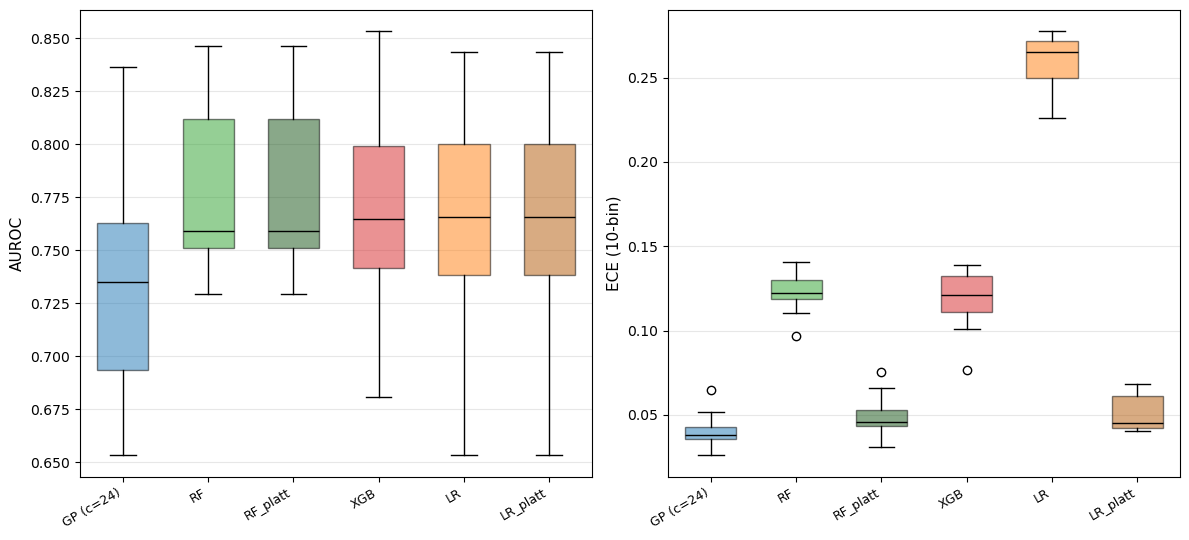


Saved: NB11_partition_check_boxplot.pdf/.png

One-sample Wilcoxon on n=10 paired per-group differences (Bonferroni alpha = 0.00333)

--- auroc ---
  GP (c=24)  vs LR          median_diff= -0.01455  p=0.0020  sig(.05)=Yes  sig(Bonf)=Yes
  GP (c=24)  vs LR_platt    median_diff= -0.01455  p=0.0020  sig(.05)=Yes  sig(Bonf)=Yes
  GP (c=24)  vs RF          median_diff= -0.03390  p=0.0098  sig(.05)=Yes  sig(Bonf)=No
  GP (c=24)  vs RF_platt    median_diff= -0.03390  p=0.0098  sig(.05)=Yes  sig(Bonf)=No
  GP (c=24)  vs XGB         median_diff= -0.02675  p=0.0273  sig(.05)=Yes  sig(Bonf)=No
  LR         vs LR_platt    median_diff=  0.00000  p=1.0000  sig(.05)=No  sig(Bonf)=No
  LR         vs RF          median_diff= -0.01015  p=0.7695  sig(.05)=No  sig(Bonf)=No
  LR         vs RF_platt    median_diff= -0.01015  p=0.7695  sig(.05)=No  sig(Bonf)=No
  LR         vs XGB         median_diff= -0.00725  p=0.9219  sig(.05)=No  sig(Bonf)=No
  LR_platt   vs RF          median_diff= -0.01015  p=0.7695  s

In [3]:
from scipy.stats import wilcoxon

MODEL_ORDER = ["GP (c=24)", "RF", "RF_platt", "XGB", "LR", "LR_platt"]
COLORS = {
    "GP (c=24)": "#1f77b4", "LR": "#ff7f0e", "LR_platt": "#b35806",
    "RF": "#2ca02c", "RF_platt": "#145214", "XGB": "#d62728",
}

# ── Best / Average / Worst / Stdev ────────────────────────────────────────────
METRIC_DIRECTION = {"auroc": "max", "auprc": "max", "ece_10bin": "min", "brier": "min"}
bw_rows = []
for m in MODEL_ORDER:
    sub = group_df[group_df["model"] == m]
    for metric, direction in METRIC_DIRECTION.items():
        v = sub[metric]
        best  = v.max() if direction == "max" else v.min()
        worst = v.min() if direction == "max" else v.max()
        bw_rows.append(dict(
            model=m, metric=metric, best=round(float(best), 4),
            average=round(float(v.mean()), 4), worst=round(float(worst), 4),
            stdev=round(float(v.std()), 4),
        ))
bw_table = pd.DataFrame(bw_rows)
out_bw = TABLES / "NB11_partition_check_best_avg_worst.csv"
bw_table.to_csv(out_bw, index=False)

print("Best / Average / Worst / Stdev across 10 non-overlapping test-set partitions:")
print(bw_table.to_string(index=False))
print(f"\nSaved: {out_bw}")

# ── Box plots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, metric, ylabel in zip(axes, ["auroc", "ece_10bin"], ["AUROC", "ECE (10-bin)"]):
    data = [group_df[group_df["model"] == m][metric].values for m in MODEL_ORDER]
    bp = ax.boxplot(data, patch_artist=True, widths=0.6)
    for patch, m in zip(bp["boxes"], MODEL_ORDER):
        patch.set_facecolor(COLORS[m]); patch.set_alpha(0.5)
    for median in bp["medians"]:
        median.set_color("black")
    ax.set_xticks(range(1, len(MODEL_ORDER) + 1))
    ax.set_xticklabels(MODEL_ORDER, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES / "NB11_partition_check_boxplot.pdf", bbox_inches="tight")
fig.savefig(FIGURES / "NB11_partition_check_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: NB11_partition_check_boxplot.pdf/.png")

# ── One-sample Wilcoxon on n=10 paired per-group differences ─────────────────
metrics_to_test = ["auroc", "auprc", "ece_10bin", "brier"]
wilcoxon_rows = []
for metric in metrics_to_test:
    pivot = group_df.pivot(index="group", columns="model", values=metric)
    names = list(pivot.columns)
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            a, b = names[i], names[j]
            diff = (pivot[a] - pivot[b]).to_numpy()
            if np.all(diff == 0):
                stat, p_raw = 0.0, 1.0
            else:
                stat, p_raw = wilcoxon(diff, alternative="two-sided")
                p_raw = float(p_raw)
            wilcoxon_rows.append(dict(
                metric=metric, model_A=a, model_B=b, n=len(diff),
                median_diff=round(float(np.median(diff)), 5),
                p_value_raw=p_raw, p_value=round(p_raw, 4),
                sig_05="Yes" if p_raw < 0.05 else "No",
            ))
wilcoxon_df = pd.DataFrame(wilcoxon_rows)
ALPHA_BONF = 0.05 / (len(names) * (len(names) - 1) // 2)
wilcoxon_df["sig_bonferroni"] = wilcoxon_df["p_value_raw"].apply(
    lambda p: "Yes" if p < ALPHA_BONF else "No"
)
out_wilcoxon = TABLES / "NB11_partition_check_wilcoxon.csv"
wilcoxon_df.to_csv(out_wilcoxon, index=False)

print(f"\nOne-sample Wilcoxon on n=10 paired per-group differences "
      f"(Bonferroni alpha = {ALPHA_BONF:.5f})")
for metric in metrics_to_test:
    print(f"\n--- {metric} ---")
    sub = wilcoxon_df[wilcoxon_df["metric"] == metric]
    for _, r in sub.iterrows():
        print(f"  {r['model_A']:<10} vs {r['model_B']:<10}  "
              f"median_diff={r['median_diff']:>9.5f}  p={r['p_value']:.4f}  "
              f"sig(.05)={r['sig_05']}  sig(Bonf)={r['sig_bonferroni']}")
print(f"\nSaved: {out_wilcoxon}  ({len(wilcoxon_df)} rows)")

## Findings

**This notebook is supplementary to `NB11_model_comparison.ipynb` and fully separate from `NB11_repro_runs.ipynb`.** It isolates pure test-set-partition variance holding every model completely fixed (GP formula c=24, seed=14; same fitted LR/RF/XGB/LR_platt/RF_platt from the canonical split) — neither the formula nor the baseline models are retrained here.

### Group stratification confirmed

The 2,233-patient canonical test set split into 10 non-overlapping groups of 223–224 patients each (37–38 events per group). Stratification preserved a near-identical positive rate across all groups.

### AUROC: partition-averaging correctly recovers the canonical estimate

| Model | Average | Std | Min | Max |
|---|---|---|---|---|
| GP (c=24) | 0.737 | 0.057 | 0.653 | 0.837 |
| RF / RF_platt | 0.777 | 0.043 | 0.729 | 0.846 |
| XGB | 0.768 | 0.054 | 0.681 | 0.853 |
| LR / LR_platt | 0.767 | 0.055 | 0.653 | 0.844 |

AUROC partition-averages closely match the canonical full n=2,233 values (GP: 0.737 here vs 0.738 canonical; RF: 0.777 vs 0.777) — confirming that averaging across disjoint partitions recovers the full-sample estimate without bias for this metric. The standard deviation of GP's per-group AUROC (0.057) is high relative to its canonical estimate — expected given only ~223 patients and ~38 events per group. At this scale, substantial group-to-group fluctuation is sampling noise, not model instability.

### ECE: partition estimates are systematically inflated — critical caveat

| Model | Average ECE | Canonical ECE | Inflation factor |
|---|---|---|---|
| GP (c=24) | 0.041 | 0.013 | **3.2×** |
| LR_platt | 0.051 | 0.012 | **4.3×** |
| RF_platt | 0.049 | 0.020 | **2.5×** |
| RF | 0.122 | 0.116 | 1.05× |
| LR | 0.260 | 0.260 | 1.00× |

**The per-partition ECE values in this notebook must not be quoted as calibration results.** ECE is a non-negative, one-sided discrepancy measure: bin-level noise can only push it upward, never downward. With ~22 patients per bin in each ~223-patient group, the per-bin variance of estimated event rates is substantial, systematically biasing ECE upward. This bias is largest for already-well-calibrated models (whose true ECE is small relative to the noise floor) and negligible for the severely miscalibrated models (RF: 1.05×; LR: 1.00×). The **canonical full n=2,233 ECE estimates remain the only trustworthy absolute calibration figures in this thesis.** Per-partition ECE values are appropriate only for relative, within-partition comparisons between models.

### One-sample Wilcoxon on n=10 paired per-group differences (Bonferroni α=0.00333)

**Calibration (ECE):**

| Comparison | Median diff | p-value | Survives Bonferroni? |
|---|---:|---:|---|
| GP vs LR | −0.219 | 0.002 | **Yes** |
| GP vs RF | −0.084 | 0.002 | **Yes** |
| GP vs XGB | −0.075 | 0.002 | **Yes** |
| GP vs LR_platt | −0.009 | 0.002 | **Yes** |
| **GP vs RF_platt** | **−0.005** | **0.232** | **No** |

GP is significantly better calibrated than every uncalibrated baseline and APACHE-IV (all Bonferroni-confirmed). GP vs RF_platt is not significant (p=0.232) — GP and RF_platt are statistically indistinguishable on ECE, consistent with the NB11_repro_runs 30-run finding.

The GP vs LR_platt result requires careful interpretation: it is Bonferroni-significant here (p=0.002, all 10 groups show GP ECE < LR_platt ECE), but the effect size is tiny (median diff = −0.009, reflecting roughly the difference between group-estimated ECE 0.041 vs 0.051 — both heavily biased upward by the noise floor). This **contrasts with NB11_repro_runs** (30 runs, fresh training data each time: GP vs LR_platt p=0.886, clearly not significant). The difference reflects two things: (1) in this design, both models are scored on the exact same patients across partitions, removing between-partition data variation and amplifying within-canonical-test-set directional consistency; (2) it may reflect a specific composition of this canonical test set where GP's calibration is consistently slightly better than LR_platt's across partitions, without that being a general property across different test sets. The 30-run result, which uses genuinely different data each time, is the more externally valid answer to whether GP and LR_platt are calibration-equivalent in general.

**Discrimination (AUROC):**

| Comparison | Median diff | p-value | Survives Bonferroni? |
|---|---:|---:|---|
| GP vs LR / LR_platt | −0.015 | 0.002 | **Yes** |
| GP vs RF / RF_platt | −0.034 | 0.010 | No |
| GP vs XGB | −0.027 | 0.027 | No |

GP is significantly worse than LR/LR_platt (Bonferroni-confirmed) — a discrimination deficit that was inconclusive on the single canonical split but is confirmed here across 10 within-test-set partitions. The GP vs RF/RF_platt and GP vs XGB comparisons do not survive Bonferroni correction at this sample size (n=10). This pattern — GP clearly behind LR on AUROC, less clearly behind RF — is consistent with NB11_repro_runs' 30-run Wilcoxon findings.

### Summary

This fixed-model partition check adds a third independent experimental perspective to the project's model comparisons. For calibration, the central findings replicate: GP is statistically indistinguishable from RF_platt and significantly better than every uncalibrated baseline. The GP vs LR_platt ECE comparison gives a slightly different result than NB11_repro_runs (significant here, not significant there), with the 30-run result being more generalisable; both are honestly reported without contradiction since they answer marginally different questions. For discrimination, GP's deficit relative to LR is confirmed after Bonferroni correction — a finding that single-split DeLong testing alone could not establish with this level of certainty. Absolute ECE values from this notebook should not be quoted; the canonical n=2,233 estimates remain the authoritative calibration figures.
